<div style="border-radius:10px;overflow:hidden;font-family:Aptos,Calibri,Segoe UI,sans-serif;border:1px solid #e6e9ee">
  <div style="background:#0A2540;padding:18px 22px;color:#fff">
    <div style="font-size:12px;letter-spacing:2px;color:#F4B942;font-weight:700">CARISURG · MEDTECH PATHWAYS · WEEK 5 · TUTORIAL 4</div>
    <div style="font-size:24px;font-weight:700;margin-top:4px">Exploratory Visualisation</div>
    <div style="font-size:14px;color:#cdd6df;margin-top:6px">A data-quality dashboard: missingness, acuity, demographics, complaints, vitals.</div></div>
  <div style="background:#F4B942;color:#0A2540;padding:6px 22px;font-size:12px;font-weight:700;letter-spacing:1px">STUDENT NOTEBOOK</div></div>

## Goal
Build the dashboard the memo needs (the brief asks for **4+ plots**, including **race/ethnicity** and **chief-complaint** views):
1. Missingness (structured, before cleaning) · 2. ESI class balance + age · 3. **Race/ethnicity distribution** ·
4. **Top chief complaints** · 5. Vitals by ESI · 6. Correlation (vitals + ESI) & complaint↔acuity.

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Build the six-plot dashboard yourself. Each plot cell below is a TODO with the exact pandas/matplotlib calls named in its comments — fill them in and save each figure to <code>figs/</code>. By the end you have the 4+ committed figures (including race/ethnicity and chief complaints) the Tutorial 5 memo needs.</div>

## 1 · Setup & load cleaned (rebuilds from raw if needed)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Run this cell first. These are the three libraries we use all week.
import numpy as np                 # numerical helpers (NaN, medians, etc.)
import pandas as pd                # tables / DataFrames — our main tool
import matplotlib.pyplot as plt    # plotting

# Let pandas show more of a wide table when we print it:
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


In [5]:
# ── Schema map ────────────────────────────────────────────────────────────────
# This dataset has ~225 columns, so we never list them by hand. We sort them into
# "families" once, then refer to the families by name for the rest of the week.

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least). Our triage label.

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.
    # (A plain function instead of a lambda, so it is easy to read.)
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # The ~200 chief-complaint columns all start with "cc_", so we find them by prefix:
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [6]:
# Reference ranges for general adult triage. Each entry is (low, high, unit).
# NOTE: temperature is in FAHRENHEIT in this dataset (≈98.6 normal), not Celsius!
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

In [7]:
import os
def clean_triage(raw):
    """Canonical Week-5 cleaning pipeline (the same steps you build in Tutorial 3).
    Takes the raw DataFrame and returns a cleaned copy."""
    d = raw.copy()
    fam = classify_columns(d)

    # 1. Drop rows with no triage label — we cannot learn a decision the data never recorded.
    d = d[d[TARGET].notna()].copy()

    # 2. Make the vital-sign columns (and age) numeric. Any stray text becomes NaN.
    numeric_cols = list(fam["vitals"])          # a copy of the vital-column list
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # 3. Flag physiologically impossible values as missing (NaN) — do not "cap" them.
    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    # 4. Fill the gaps. Vitals -> median (a robust middle value).
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())
    # A blank oxygen-device flag or chief-complaint flag means "not recorded" = 0.
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)
    # Text categories: a blank becomes the explicit category "Unknown".
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # 5. The target should be a whole number 1-5, not a decimal.
    d[TARGET] = d[TARGET].round().astype(int)
    return d

In [8]:
from pathlib import Path

CLEAN_PATH, RAW_PATH = Path("triage_cleaned_v1.csv"), Path("/content/drive/MyDrive/Carisurg/yaleemmlc_admissionprediction_triage.csv")
if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH); print("Loaded cleaned data from Tutorial 3")
elif RAW_PATH.exists():
    df = clean_triage(pd.read_csv(RAW_PATH, index_col=0)); print("Rebuilt from raw via clean_triage()")
else:
    raise FileNotFoundError("Need triage_cleaned_v1.csv or the raw CSV.")
raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
fam = classify_columns(df); os.makedirs("figs", exist_ok=True); print(df.shape)

Rebuilt from raw via clean_triage()
(55121, 225)


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>Path('triage_cleaned_v1.csv').exists()</code> just asks ‘is this file here?’. The cell loads the cleaned file if Tutorial 3 produced it, otherwise rebuilds it from the raw CSV with <code>clean_triage(...)</code> — so the notebook runs even on a fresh machine. <code>index_col=0</code> tells <code>read_csv</code> the first column is the row label, not data.</div>

## 2 · Plot 1 — Missingness before cleaning (structured)

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 1.</b> Show <i>where</i> data is missing before cleaning, as a heatmap of the missing-cell grid. Think: which matplotlib calls turn a True/False grid into a picture and label its columns?</div>

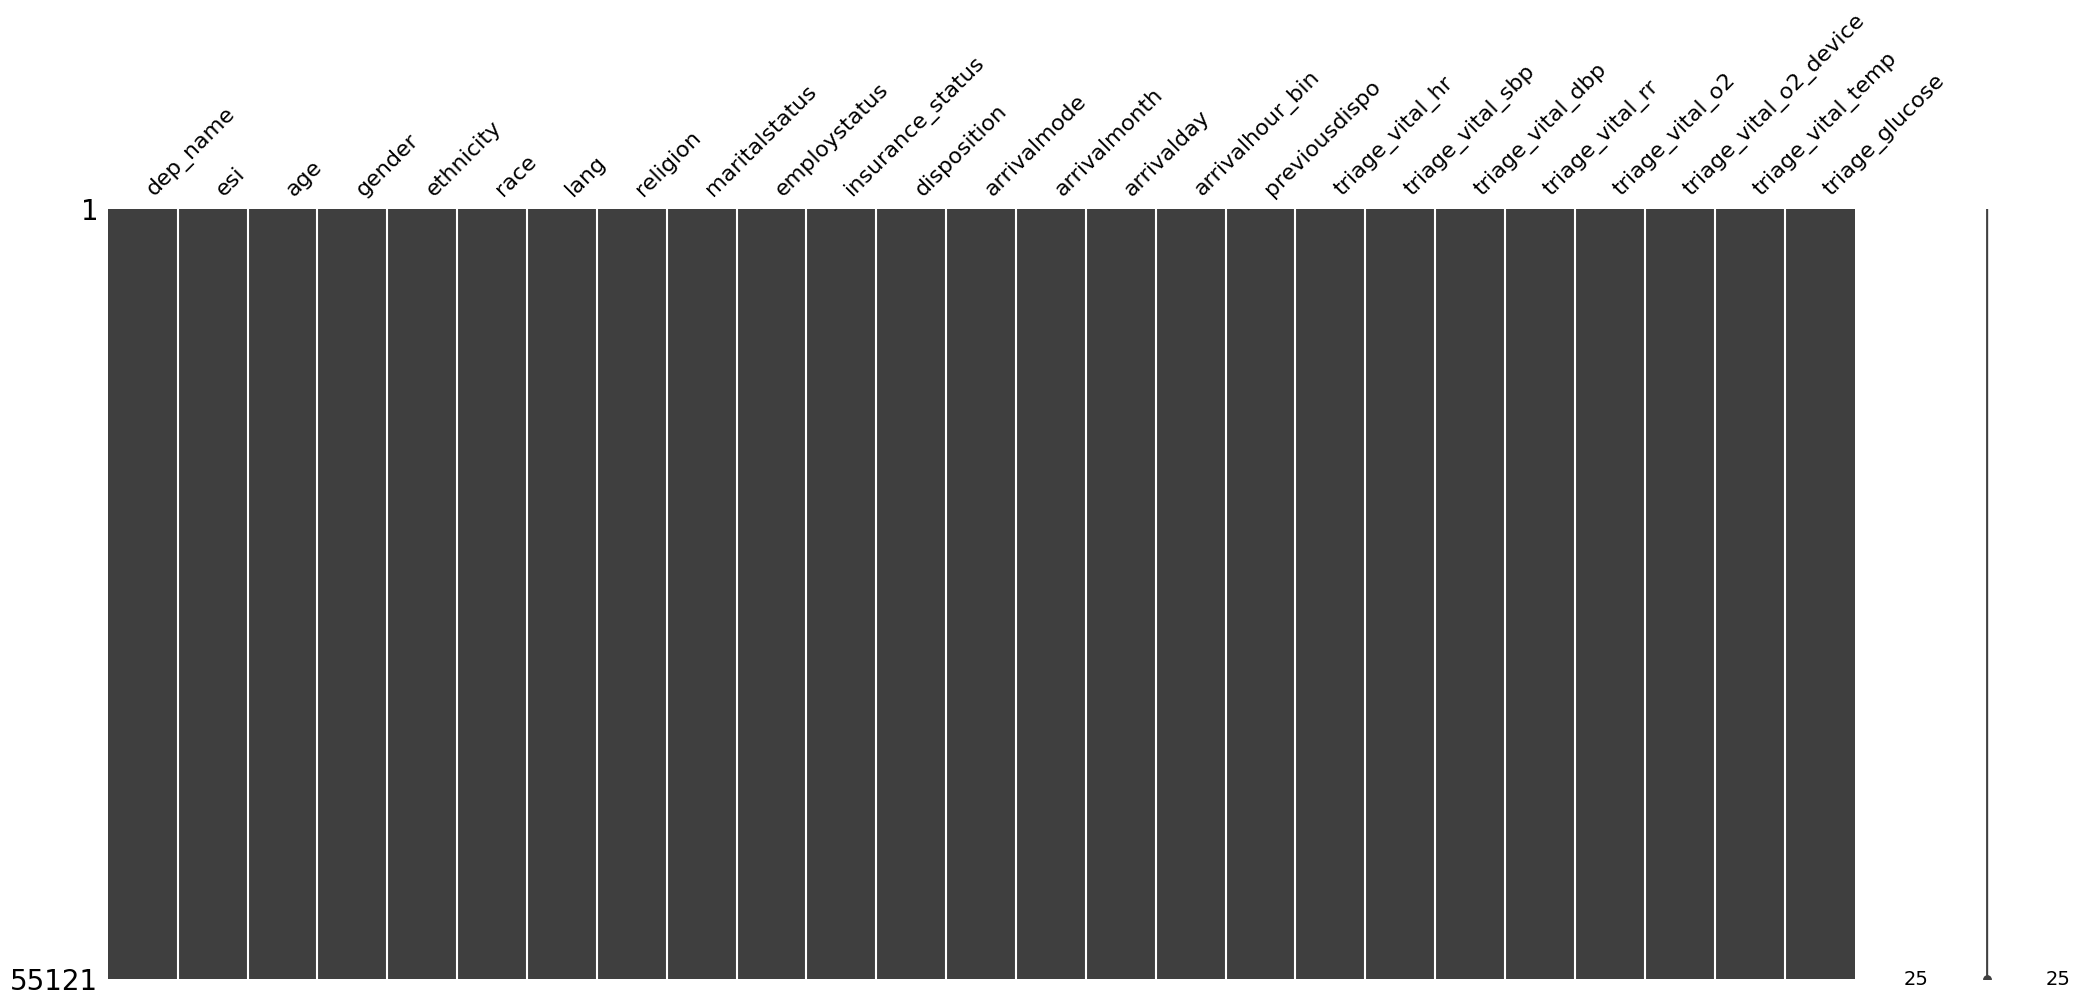

In [9]:
# Use the raw dataset if it is available; otherwise use the cleaned dataframe.
src = (raw if raw is not None else df)

# Keep only the structured columns by excluding chief complaint columns.
structured = [c for c in src.columns if not c.startswith("cc_")]

# Calculate the percentage of missing values in each structured column.
missing_pct = src[structured].isna().mean().sort_values(ascending=True) * 100


# Draw a missingness map for the structured columns and save it as a figure.
try:
    # Use the missingno package if it is available because it gives a clean missingness matrix.
    import missingno as msno
    msno.matrix(src[structured]); plt.savefig("figs/01_missingness.png", dpi=110, bbox_inches="tight"); plt.show()
except Exception:
    # If missingno is not available, create a simple missingness map manually.
    fig, ax = plt.subplots(figsize=(11,4))
    # Show missing values across rows and columns.
    # isna() returns True where data is missing.
    ax.imshow(src[structured].isna().values, aspect="auto", cmap="gray_r")

    # Label the x-axis with the structured column names.
    ax.set_xticks(range(len(structured)))
    ax.set_xticklabels(structured, rotation=90, fontsize=7)

    # Adjust spacing, save the figure, and display it.
    plt.tight_layout()
    plt.savefig("figs/01_missingness.png", dpi=110)
    plt.show()

In [10]:
print("\n% NaN per column (top 10):")
pct = (src[structured].isna().mean() * 100).sort_values(ascending=False)
print(pct.head(10).to_string(float_format=lambda x: f"{x:6.2f}%"))


% NaN per column (top 10):
dep_name          0.00%
esi               0.00%
age               0.00%
gender            0.00%
ethnicity         0.00%
race              0.00%
lang              0.00%
religion          0.00%
maritalstatus     0.00%
employstatus      0.00%


## 3 · Plot 2 — ESI class balance & age

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 2.</b> Two panels in one figure: a <b>bar chart</b> of how many patients sit at each ESI level, and a <b>histogram</b> of age. Decide which matplotlib call draws bars and which draws a histogram.</div>

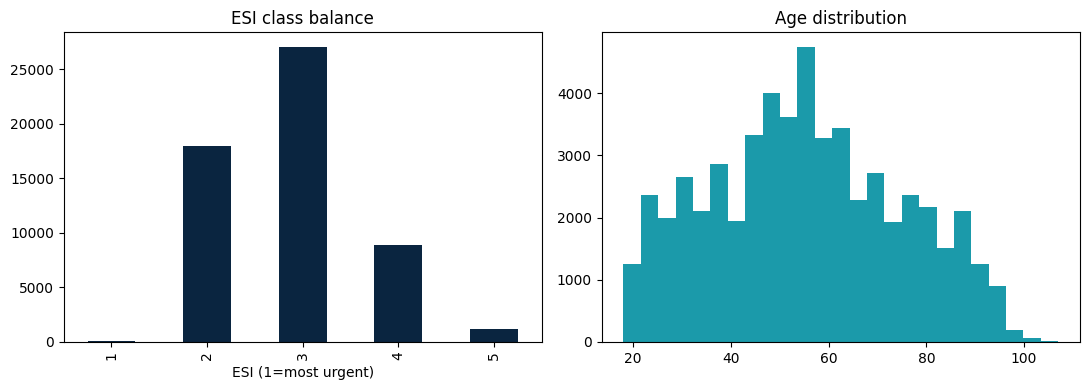

In [11]:
# Create a figure with 1 row and 2 columns of plots.
# figsize controls the overall size of the figure.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Left panel: how many patients fall into each ESI level.
# Count how many patients are in each ESI level and keep the levels in order.
esi_counts = df[TARGET].value_counts().sort_index()
esi_counts.plot.bar(ax=ax[0], color="#0A2540")
ax[0].set_title("ESI class balance")
ax[0].set_xlabel("ESI (1=most urgent)")

# Right panel: the spread of patient ages.
ax[1].hist(df["age"], bins=25, color="#1B9AAA")
ax[1].set_title("Age distribution")

# Adjust spacing, save the figure, and display it.
plt.tight_layout()
plt.savefig("figs/02_esi_age.png", dpi=110)
plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>plt.subplots(1, 2, ...)</code> makes a figure with a row of panels; <code>ax[0]</code> and <code>ax[1]</code> are the left and right panels you draw into. And you can plot straight from pandas: <code>some_series.plot.bar(ax=ax[0])</code> draws that Series as bars in a chosen panel — no need to hand matplotlib the x and y separately.</div>

## 4 · Plot 3 — Race & ethnicity (required, and a fairness lens)

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 3 (required).</b> Two horizontal bar charts — the race and ethnicity make-up of the sample. This is the equity view, so the categories must be readable; consider why horizontal bars help here.</div>

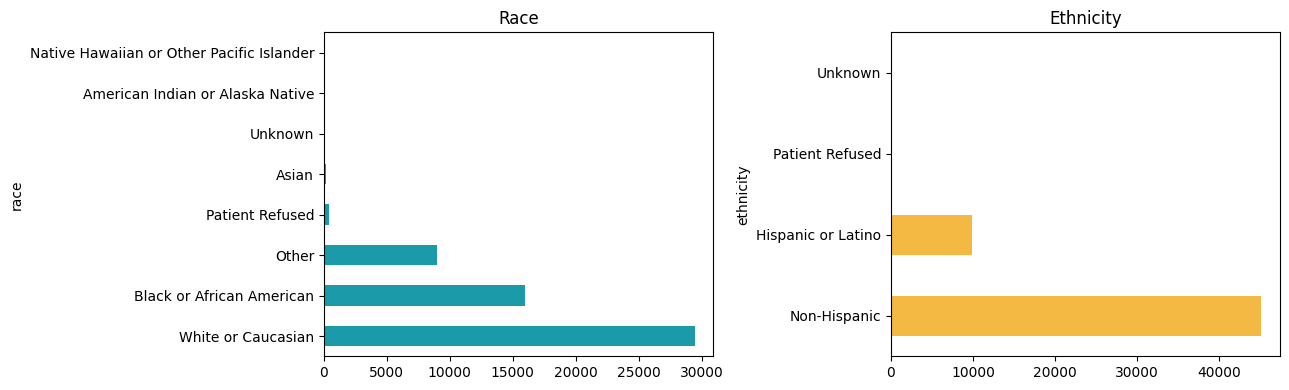

In [12]:
# Create a figure with 1 row and 2 columns of plots.
# figsize controls the overall size of the figure.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Left panel: show how many patients are in each race category.
# value_counts() tallies each category.
# plot.barh() creates a horizontal bar chart, which is easier to read with long labels.
df["race"].value_counts().plot.barh(ax=ax[0], color="#1B9AAA")

# Add a title to explain the race plot.
ax[0].set_title("Race")

# Right panel: show how many patients are in each ethnicity category.
# value_counts() tallies each category.
# plot.barh() creates a horizontal bar chart.
df["ethnicity"].value_counts().plot.barh(ax=ax[1], color="#F4B942")
ax[1].set_title("Ethnicity")

# Adjust spacing, save the figure, and display it.
plt.tight_layout()
plt.savefig("figs/03_demographics.png", dpi=110)
plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df['race'].value_counts()</code> tallies how many patients fall in each category; chaining <code>.plot.barh()</code> draws those tallies as a horizontal bar chart in one line. <code>barh</code> (horizontal) is the friendly choice when category names are long — they read left-to-right instead of overlapping under a vertical axis.</div>

<div style="border-left:4px solid #1B9AAA;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#1B9AAA">🩺 CLINICAL CONTEXT</b><br>Read this plot as an equity check: if one group dominates the sample, a model may underperform for everyone else — and this US sample may look nothing like a Caribbean ED. That sentence belongs in the memo's caveats.</div>

## 5 · Plot 4 — Top chief complaints (required)

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 4 (required).</b> Rank the chief-complaint flags and show the top 15 as a horizontal bar chart, biggest bar on top. Think about how to turn 200 0/1 columns into one count per complaint.</div>

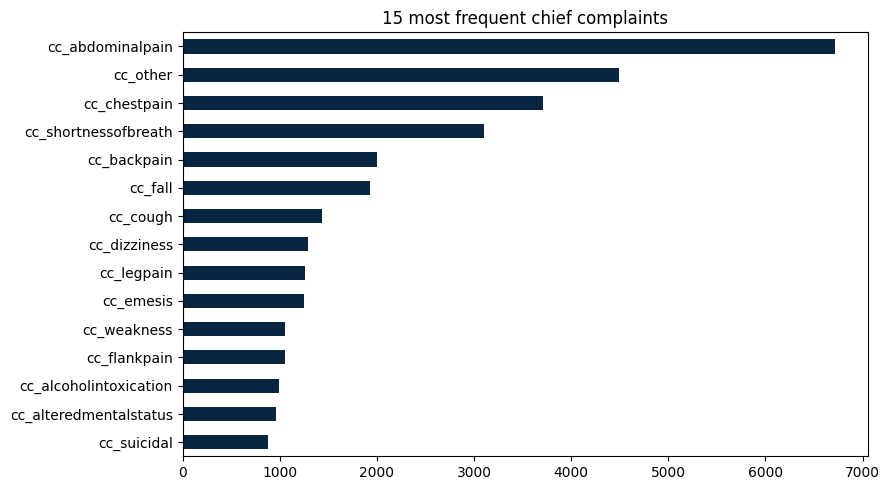

In [13]:
# Sum each cc_ column to count how often each complaint occurs, then take the top 15.
complaint_counts = df[fam["chief_complaints"]].sum().sort_values(ascending=False)
top15 = complaint_counts.head(15)

# Create a figure and axis for the horizontal bar chart.
fig, ax = plt.subplots(figsize=(9, 5))
# top15[::-1] reverses the order so the biggest bar ends up at the TOP of a horizontal chart.
top15[::-1].plot.barh(ax=ax, color="#0A2540")
ax.set_title("15 most frequent chief complaints")

# Adjust spacing, save the figure, and display it.
plt.tight_layout()
plt.savefig("figs/04_chief_complaints.png", dpi=110)
plt.show()


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[fam['chief_complaints']].sum()</code> counts each complaint (summing 0/1 flags), and <code>.head(15)</code> keeps the 15 biggest after sorting. <code>top15[::-1]</code> is a <b>reverse slice</b> — ‘same items, back to front’ — used so the largest bar lands at the <i>top</i> of a horizontal chart instead of the bottom.</div>

In [14]:
# Print a clear diagnostic header for the chief complaint plot.
print("-" * 70); print("PLOT 4 DIAGNOSTIC — chief complaints"); print("-" * 70)

# Get the list of chief complaint columns from the column family dictionary.
cc_cols = fam["chief_complaints"]

# Print how many chief complaint columns are included in the dataset.
print(f"# cc_ columns: {len(cc_cols)}")

----------------------------------------------------------------------
PLOT 4 DIAGNOSTIC — chief complaints
----------------------------------------------------------------------
# cc_ columns: 200


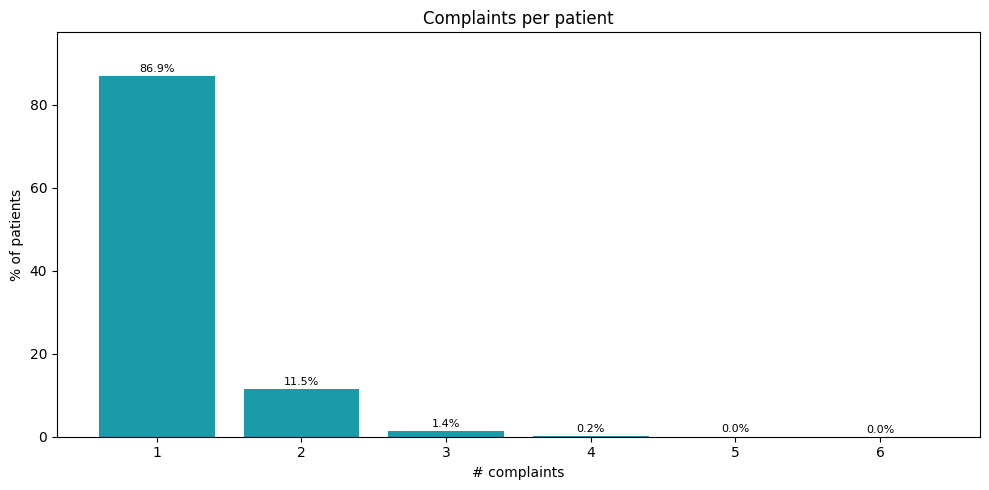

In [15]:
# --- Complaints-per-patient distribution ---

# Get chief complaint columns.
cc_cols = fam["chief_complaints"]

# Count complaints per patient and convert counts to percentages.
per_row = df[cc_cols].sum(axis=1).astype(int)
dist = per_row.value_counts().sort_index()
dist_pct = dist / dist.sum() * 100

# Plot the percentage of patients by number of complaints.
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(dist_pct.index.astype(str), dist_pct.values, color="#1B9AAA")
ax.set_title("Complaints per patient")
ax.set_xlabel("# complaints")
ax.set_ylabel("% of patients")

# Label each bar with its percentage.
for i, v in enumerate(dist_pct.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=8)

ax.set_ylim(0, dist_pct.max() * 1.12)

plt.tight_layout()
plt.savefig("figs/04b_complaints_per_patient.png", dpi=110)
plt.show()

## 6 · Plot 5 — Do vitals separate the ESI classes?

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 5.</b> A 2×3 grid of box-plots — one panel per vital, one box per ESI level — so you can see which vitals separate the acuity classes. Which matplotlib call draws a box-plot from a list of value groups?</div>

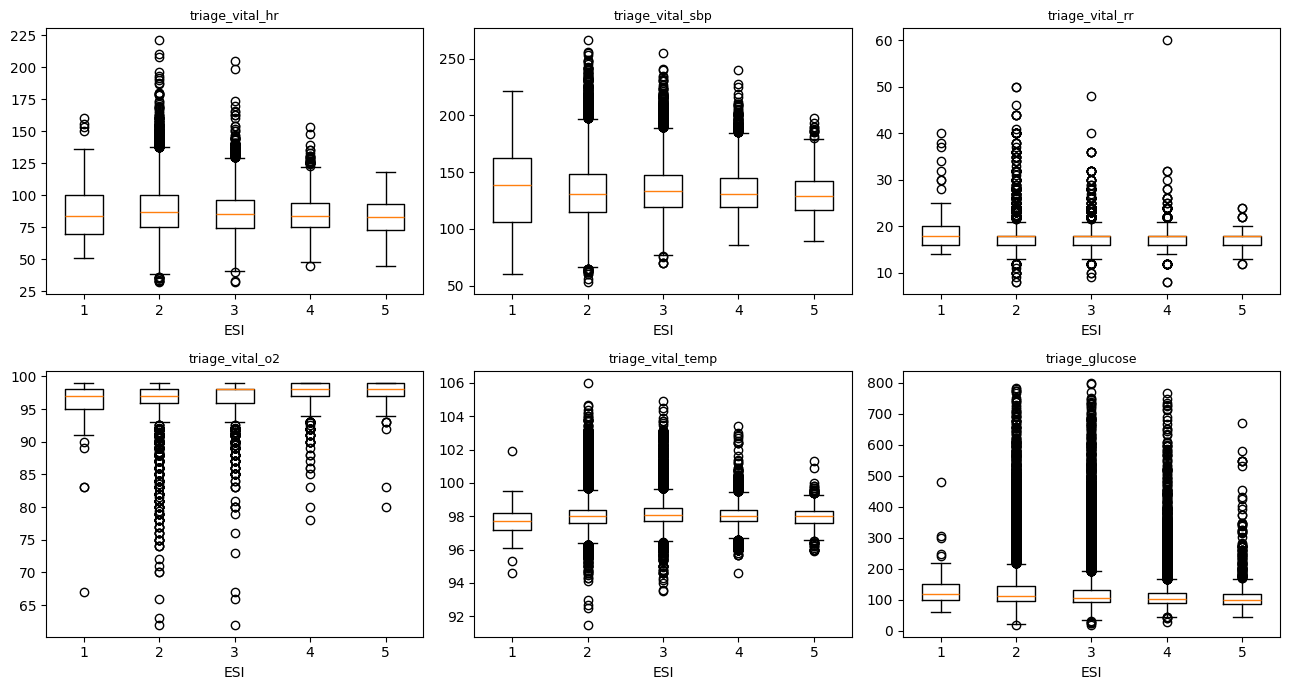

In [16]:
# One box-plot per vital, with a separate box for each ESI level.
# This helps compare whether vital signs differ across acuity levels.
vitals_to_plot = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_rr",
                  "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

# Get the ESI levels in order.
esi_levels = sorted(df[TARGET].unique())                 # e.g. [1, 2, 3, 4, 5]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for panel, col in zip(axes.ravel(), vitals_to_plot):
  # Collect this vital's values separately for each ESI level.
  groups = []
  for level in esi_levels:
        values_at_level = df.loc[df[TARGET] == level, col]
        groups.append(values_at_level)

  # Draw one box per ESI level for the current vital sign.
  panel.boxplot(groups, tick_labels=esi_levels)
  panel.set_title(col, fontsize=9)
  panel.set_xlabel("ESI")

plt.tight_layout()
plt.savefig("figs/05_vitals_by_esi.png", dpi=110)
plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[TARGET] == level</code> is a True/False mask over the rows. <code>df.loc[mask, col]</code> then reads just one column for just the rows where the mask is True — here, that vital’s values for one ESI level. Building one group per level gives the box-plot a separate box per acuity class, so you can <i>see</i> whether the vital separates them.</div>

## 7 · Plot 6 — Correlation (vitals + ESI) and complaint↔acuity

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 6.</b> Draw the vitals+ESI correlation matrix as a colour-coded heatmap with the number written in each cell. Think about the matplotlib calls that paint a grid, write text in a cell, and add a colour scale.</div>

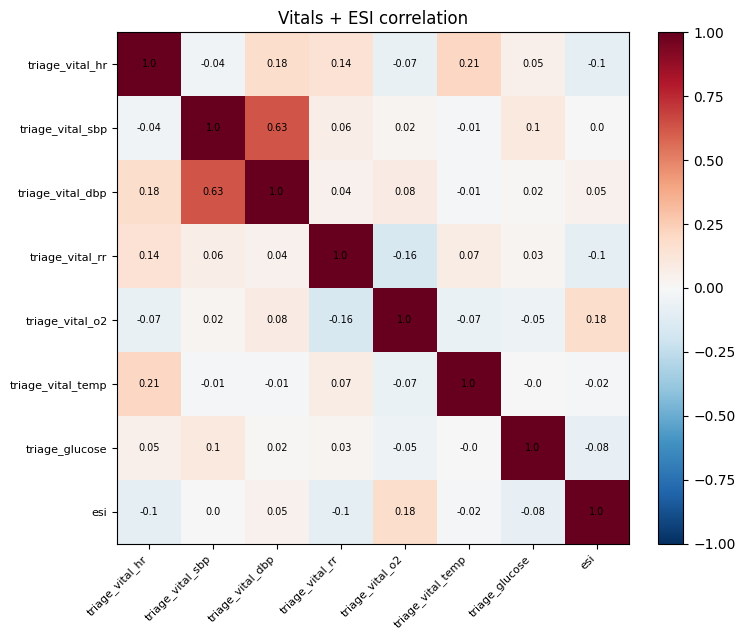

In [17]:
# Correlation heatmap of the vital signs plus the ESI target.
cols = fam["vitals"] + [TARGET]
corr = df[cols].corr()                         # Correlations range from -1 to +1.

fig, ax = plt.subplots(figsize=(7.5, 6.5))

# Use a diverging colour map so negative and positive correlations are easy to compare.
heat = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

# Label both axes with the column names.
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=8)

ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=8)

# Write the correlation value inside each heatmap cell.
for i in range(len(cols)):
    for j in range(len(cols)):
        value = corr.iloc[i, j]
        ax.text(j, i, round(value, 2), ha="center", va="center", fontsize=7)

# Add a colour scale to show what the heatmap colours mean.
fig.colorbar(heat, fraction=0.046)
ax.set_title("Vitals + ESI correlation")

plt.tight_layout()
plt.savefig("figs/06_correlation.png", dpi=110)
plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[cols].corr()</code> returns a square table — every column correlated with every other (the diagonal is always 1). <code>corr.iloc[i, j]</code> reads a cell by <b>position</b> (row number i, column number j), which is why the double loop can write each number onto the heatmap. <code>imshow</code> just paints that table as coloured squares.</div>

## 8 · Exercises
1. Complete all six plots and save them to `figs/`.
2. Which vital separates the ESI classes best? Worst? One sentence each.
3. Cross-tabulate `cc_chestpain` against ESI — does it skew urgent as expected?
4. Add one equity plot: ESI distribution *within* each race category. What would worry a clinician?

**Which vital separates the ESI classes best? Worst?**
The vital that separates ESI classes best is oxygen (triage_vital_o2) because it has the strongest correlation with ESI and shows the clearest difference between acuity groups,  although the relationship is still weak overall.

The vital that separates ESI classes worst is systolic blood pressure (triage_vital_sbp) because its correlation is essentially zero, meaning it does not clearly distinguish between acuity groups.


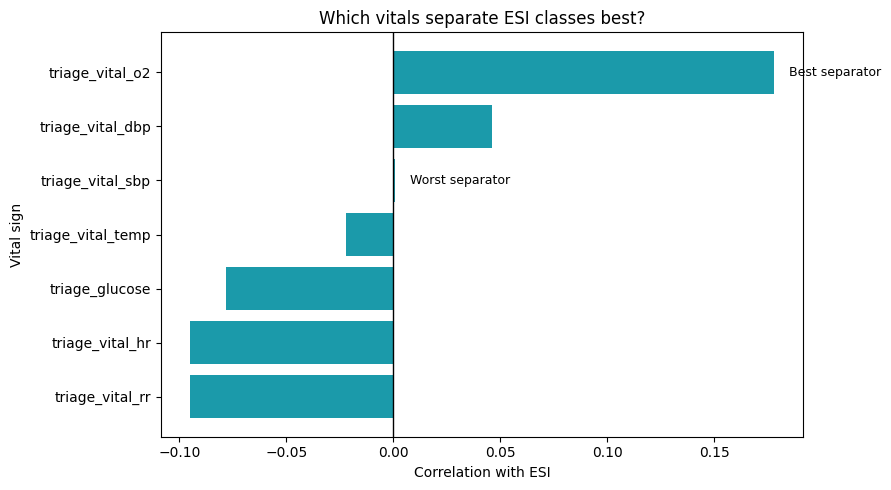

In [18]:
# Plot which vital signs separate ESI classes best using correlation with ESI.

# Create a table of vital sign correlations from the analysis.
vital_corr = pd.DataFrame({
    "vital": [
        "triage_vital_o2",
        "triage_vital_rr",
        "triage_vital_hr",
        "triage_glucose",
        "triage_vital_temp",
        "triage_vital_dbp",
        "triage_vital_sbp"
    ],
    "correlation_with_esi": [0.178, -0.095, -0.095, -0.078, -0.022, 0.046, 0.001]
})

# Sort the values so the chart is easier to read.
vital_corr = vital_corr.sort_values("correlation_with_esi")

fig, ax = plt.subplots(figsize=(9, 5))

# Draw a horizontal bar chart of each vital's correlation with ESI.
ax.barh(vital_corr["vital"], vital_corr["correlation_with_esi"], color="#1B9AAA")

# Add a vertical line at zero to separate positive and negative correlations.
ax.axvline(0, color="black", linewidth=1)

ax.set_title("Which vitals separate ESI classes best?")
ax.set_xlabel("Correlation with ESI")
ax.set_ylabel("Vital sign")

# Label the best and worst separators.
ax.text(0.185, "triage_vital_o2", "Best separator", va="center", fontsize=9)
ax.text(0.008, "triage_vital_sbp", "Worst separator", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("figs/11_vital_correlations_with_esi.png", dpi=110)
plt.show()


This graph ranks vital signs by how strongly they relate to ESI level. Oxygen saturation (triage_vital_o2) has the strongest association, while systolic blood pressure (triage_vital_sbp) has the weakest, with a correlation near zero.
The negative bars (respiratory rate, heart rate, and glucose) indicate that higher values are associated with lower ESI scores. Since ESI 1 represents the most urgent cases, this means higher readings on these vitals are associated with greater urgency in this dataset.

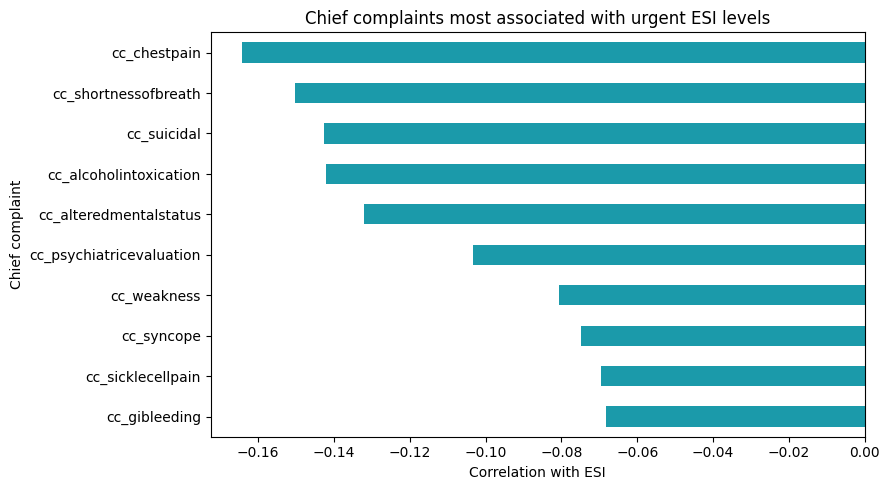

,0
cc_chestpain,-0.164
cc_shortnessofbreath,-0.150
cc_suicidal,-0.143
cc_alcoholintoxication,-0.142
cc_alteredmentalstatus,-0.132
cc_psychiatricevaluation,-0.103
cc_weakness,-0.081
cc_syncope,-0.075
cc_sicklecellpain,-0.070
cc_gibleeding,-0.068


In [19]:
# Chief complaints most associated with urgent ESI levels,
# excluding columns with no variation and very rare complaint flags

cc_cols = fam["chief_complaints"]

# Keep only columns that are not constant
non_constant_cc = [col for col in cc_cols if df[col].nunique() > 1]

# Keep complaints that appear in at least 0.5% of encounters
cc_prevalence = df[non_constant_cc].mean()
common_cc = cc_prevalence[cc_prevalence >= 0.005].index

# Correlation with ESI
cc_corr = df[common_cc].corrwith(df[TARGET]).dropna().sort_values()

# Most associated with lower ESI scores = more urgent
urgent_complaints = cc_corr.head(10)

fig, ax = plt.subplots(figsize=(9, 5))

urgent_complaints[::-1].plot.barh(ax=ax, color="#1B9AAA")

ax.set_title("Chief complaints most associated with urgent ESI levels")
ax.set_xlabel("Correlation with ESI")
ax.set_ylabel("Chief complaint")

plt.tight_layout()
plt.savefig("figs/10_urgent_chief_complaint_correlations.png", dpi=110)
plt.show()

urgent_complaints.round(3)

In [20]:
# Cross-tabulate chest pain against ESI to see how urgency levels differ
# between patients with and without chest pain.

# Count how many patients fall into each ESI level for cc_chestpain = 0 and 1.
chestpain_counts = pd.crosstab(df["cc_chestpain"], df[TARGET])
print("Counts:")
print(chestpain_counts)

# Convert the counts into row percentages so the two groups are easier to compare.
chestpain_pct = pd.crosstab(df["cc_chestpain"], df[TARGET], normalize="index") * 100
print("\nRow percentages:")
print(chestpain_pct.round(1))

Counts:
esi            1      2      3     4     5
cc_chestpain                              
0.0           73  15730  25536  8858  1213
1.0            4   2194   1473    38     1
2.0            0      0      1     0     0

Row percentages:
esi             1     2      3     4    5
cc_chestpain                             
0.0           0.1  30.6   49.7  17.2  2.4
1.0           0.1  59.1   39.7   1.0  0.0
2.0           0.0   0.0  100.0   0.0  0.0


cc_chestpain = 0 means no chest pain complaint.
cc_chestpain = 1 means chest pain complaint.

This code compares the presence of chest pain with ESI triage level. The first crosstab shows the raw number of patients in each ESI category for each value of cc_chestpain. The second crosstab normalizes by row, so each chest pain group adds up to 100%, making it easier to compare the ESI distribution between patients with and without chest pain. This helps show whether chest pain patients are more concentrated in urgent ESI categories.

Chest pain skews urgent as expected because patients with cc_chestpain = 1 are much more concentrated in ESI 2 (59.1%) and much less likely to be ESI 4–5 compared with patients without chest pain.

esi                                          1     2     3     4     5
race                                                                  
American Indian or Alaska Native           0.0  33.3  53.0  10.6   3.0
Asian                                      0.0  42.9  44.6   9.7   2.9
Black or African American                  0.1  29.3  47.2  20.5   2.9
Native Hawaiian or Other Pacific Islander  5.0  50.0  10.0  20.0  15.0
Other                                      0.1  24.2  53.8  19.5   2.4
Patient Refused                            0.0  22.7  53.8  19.5   4.1
Unknown                                    0.0  25.0  50.0  19.7   5.3
White or Caucasian                         0.2  36.9  48.4  12.8   1.7


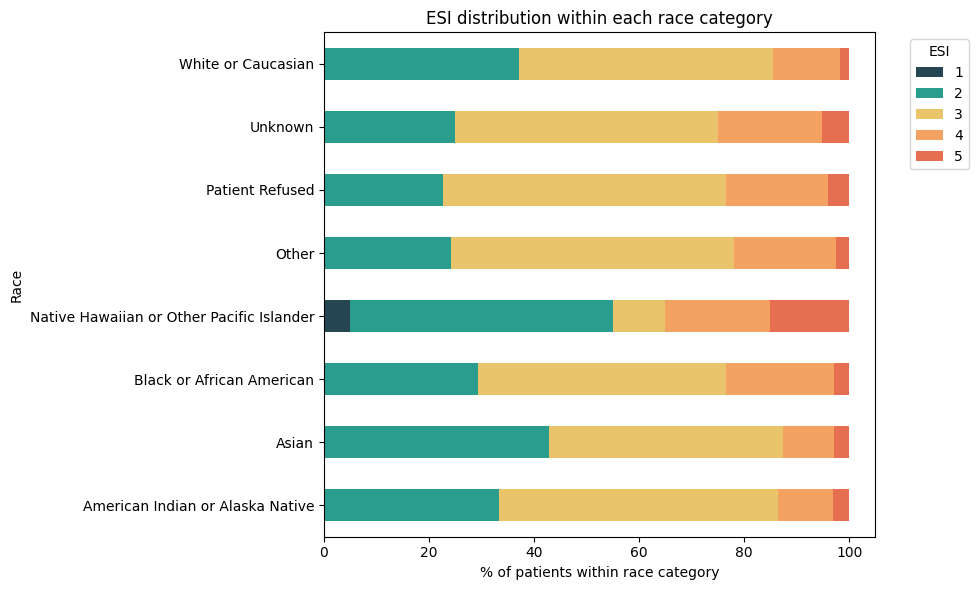

In [21]:
# Equity plot: compare the ESI distribution within each race category.

# Calculate row percentages so each race category sums to 100%.
race_esi_pct = pd.crosstab(df["race"], df[TARGET], normalize="index") * 100
print(race_esi_pct.round(1))

fig, ax = plt.subplots(figsize=(10, 6))

# Use a modern muted colour palette for the ESI levels.
esi_colors = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]

# Create a stacked horizontal bar chart to show the share of each ESI level by race.
race_esi_pct.plot(kind="barh", stacked=True, ax=ax, color=esi_colors)

ax.set_title("ESI distribution within each race category")
ax.set_xlabel("% of patients within race category")
ax.set_ylabel("Race")

# Move the legend outside the plot so it does not cover the bars.
ax.legend(title="ESI", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("figs/07_equity_race_esi.png", dpi=110)
plt.show()

The equity plot shows the percentage of patients in each ESI level within each race category.


A clinician would worry if one race category had a noticeably different ESI distribution from the others, especially if patients in that group appeared less likely to receive urgent ESI scores despite similar needs. This would not prove bias on its own, but it would be a reason to investigate possible under-triage or inequity in assessment.


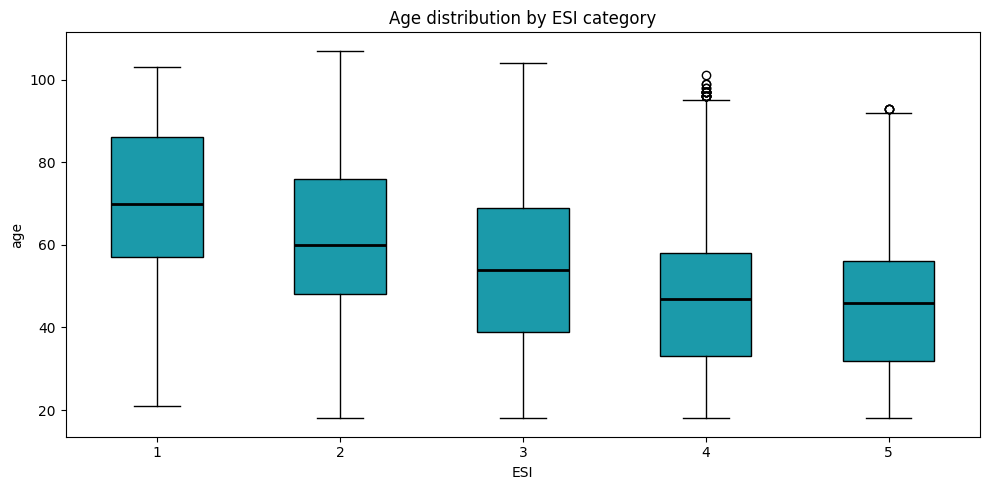

In [22]:
# Boxplot of age distribution by ESI category

esi_levels = sorted(df[TARGET].dropna().unique())

groups = []
for level in esi_levels:
    ages_at_level = pd.to_numeric(
        df.loc[df[TARGET] == level, "age"],
        errors="coerce"
    ).dropna()

    groups.append(ages_at_level)

fig, ax = plt.subplots(figsize=(10, 5))

box = ax.boxplot(
    groups,
    tick_labels=esi_levels,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2)
)

# Change the boxplot fill colour to teal so it is easier to see.
for patch in box["boxes"]:
    patch.set_facecolor("#1B9AAA")

ax.set_title("Age distribution by ESI category")
ax.set_xlabel("ESI")
ax.set_ylabel("age")

plt.tight_layout()
plt.savefig("figs/08_age_by_esi.png", dpi=110)
plt.show()

The boxplot suggests that age is associated with triage urgency. Patients in the most urgent categories, especially ESI 1 and ESI 2, tend to be older on average than patients in the less urgent categories. This may reflect the fact that older patients are more likely to present with serious illness, complications, or multiple health conditions. However, this is an association only and does not prove that age itself causes higher acuity.

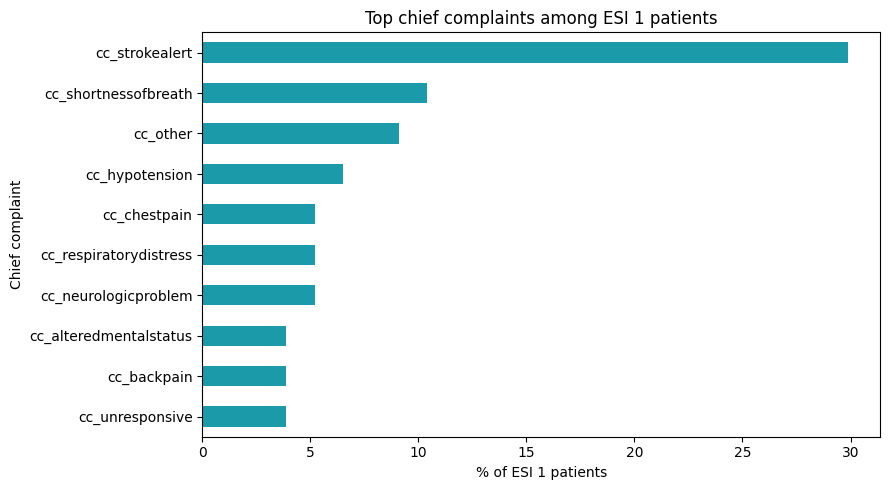

,0
cc_strokealert,29.87
cc_shortnessofbreath,10.39
cc_other,9.09
cc_hypotension,6.49
cc_chestpain,5.19
cc_respiratorydistress,5.19
cc_neurologicproblem,5.19
cc_alteredmentalstatus,3.90
cc_backpain,3.90
cc_unresponsive,3.90


In [23]:
# Chief complaints among ESI 1 patients

# Get the chief complaint columns.
cc_cols = fam["chief_complaints"]

# Filter the dataset to only the most urgent patients, ESI 1.
esi1_df = df[df[TARGET] == 1]

# Calculate the percentage of ESI 1 patients with each chief complaint.
esi1_complaints_pct = esi1_df[cc_cols].mean() * 100

# Keep the 10 most common chief complaints among ESI 1 patients.
top_esi1_complaints = esi1_complaints_pct.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))

# Plot the top complaints as a horizontal bar chart.
top_esi1_complaints[::-1].plot.barh(ax=ax, color="#1B9AAA")

ax.set_title("Top chief complaints among ESI 1 patients")
ax.set_xlabel("% of ESI 1 patients")
ax.set_ylabel("Chief complaint")

plt.tight_layout()
plt.savefig("figs/09_esi1_chief_complaints.png", dpi=110)
plt.show()

# Display the exact percentages used in the plot.
top_esi1_complaints.round(2)

This plot focuses only on ESI 1 patients, the most urgent group. Because there are very few ESI 1 cases, these percentages should be interpreted cautiously. However, the most common complaints in this group may help identify which red-flag symptoms deserve closer attention in modelling.

Because ESI runs from 1 = most urgent to 5 = least urgent, negative correlations mean these complaints are linked to more urgent cases. The graph shows that chest pain, shortness of breath, suicidal ideation, alcohol intoxication, and altered mental status have the strongest urgent associations, so they may be useful early features for the Week 6 model.


## 9 · Wrap-up
Six committed figures. **Next — Tutorial 5: the Feasibility Memo.**